# EDA Analysis
Checking if the parsed energy commodity data needs normalization (UOM, Currency, Outliers, etc.).

*Note: This notebook executes all aggregations server-side on Snowflake to handle the 163M row scale efficiently.*

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from utility.snowflake_client import SnowflakeClient

sns.set_theme(style="whitegrid")
sf = SnowflakeClient()
sf.connect()

## 1. Basic Information & Missing Values (Before Normalization)
Let's see the total scale of the dataset and how many values are missing.

In [22]:
query_info = """
SELECT 
    COUNT(*) as TOTAL_ROWS,
    COUNT(VALUE) as NON_NULL_VALUES,
    COUNT(PRODUCT) as NON_NULL_PRODUCTS,
    COUNT(DISTINCT PRODUCT) as UNIQUE_PRODUCTS,
    COUNT(DISTINCT UOM) as UNIQUE_UOMS,
    COUNT(DISTINCT CURRENCY) as UNIQUE_CURRENCIES
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
"""
df_info = sf.read_sql(query_info)
df_info

,TOTAL_ROWS,NON_NULL_VALUES,NON_NULL_PRODUCTS,UNIQUE_PRODUCTS,UNIQUE_UOMS,UNIQUE_CURRENCIES
0,162685188,162685188,162685188,6345,29,42


## 2. Top Products
What are the most frequent products in the dataset?

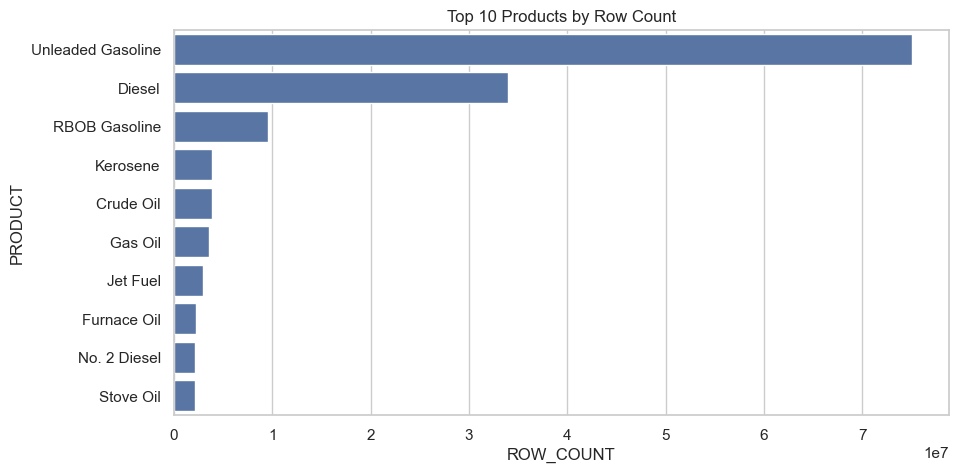

In [23]:
query_top_products = """
SELECT PRODUCT, COUNT(*) as ROW_COUNT
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
GROUP BY PRODUCT
ORDER BY ROW_COUNT DESC
LIMIT 10
"""
df_top = sf.read_sql(query_top_products)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top, y='PRODUCT', x='ROW_COUNT', color='b')
plt.title('Top 10 Products by Row Count')
plt.show()

## 3. UOM & Currency Variations
Do we have the same `PRODUCT` traded in multiple `UOM` (Units of Measure) or `CURRENCY`? If so, this requires normalization before modeling.

In [24]:
query_variations = """
SELECT 
    PRODUCT, 
    COUNT(DISTINCT UOM) as NUM_UOMS, 
    COUNT(DISTINCT CURRENCY) as NUM_CURRENCIES,
    COUNT(*) as TOTAL_ROWS
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
GROUP BY PRODUCT
HAVING NUM_UOMS > 1 OR NUM_CURRENCIES > 1
ORDER BY TOTAL_ROWS DESC
LIMIT 10
"""
df_vars = sf.read_sql(query_variations)
print("Products with multiple UOMs or Currencies:")
df_vars

Products with multiple UOMs or Currencies:


,PRODUCT,NUM_UOMS,NUM_CURRENCIES,TOTAL_ROWS
0,Unleaded Gasoline,2,2,75079777
1,Diesel,3,4,33972171
2,RBOB Gasoline,3,3,9513739
3,Kerosene,5,5,3886410
4,Crude Oil,6,4,3878059
5,Gas Oil,4,2,3564289
6,Jet Fuel,2,3,2938822
7,Furnace Oil,2,2,2193822
8,No. 2 Diesel,2,2,2164431
9,Stove Oil,2,2,2131898


In [25]:
query_uom_splits = """
SELECT 
    PRODUCT, 
    UOM, 
    CURRENCY, 
    COUNT(*) as ROW_COUNT
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
WHERE PRODUCT IN (
    SELECT PRODUCT FROM (
        SELECT PRODUCT, COUNT(*) as cnt 
        FROM CMDTYA.PUBLIC.PRICEDATA_PARSED 
        GROUP BY PRODUCT ORDER BY cnt DESC LIMIT 3
    )
)
GROUP BY PRODUCT, UOM, CURRENCY
ORDER BY PRODUCT, ROW_COUNT DESC
"""
df_splits = sf.read_sql(query_uom_splits)
print("UOM/Currency splits for top 3 products:")
df_splits

UOM/Currency splits for top 3 products:


,PRODUCT,UOM,CURRENCY,ROW_COUNT
0,Diesel,GAL,USC,24170130
1,Diesel,GAL,USD,7364381
2,Diesel,LTR,CAC,2426115
3,Diesel,N/A,N/A,11545
4,RBOB Gasoline,GAL,USD,8152651
5,RBOB Gasoline,BBL,USD,1206408
6,RBOB Gasoline,GAL,USC,133235
7,RBOB Gasoline,N/A,N/A,21445
8,Unleaded Gasoline,GAL,USC,68234530
9,Unleaded Gasoline,LTR,CAC,6845247


## 4. Value Distributions & Outliers (Before Normalization)
Let's look at the basic statistics (min, max, mean) for the top products. If the range is extremely wide or negative values exist, we may need clipping or Z-score normalization.

In [26]:
query_stats = """
SELECT 
    PRODUCT, 
    UOM, 
    CURRENCY, 
    COUNT(*) as ROW_COUNT,
    MIN(VALUE) as MIN_VAL,
    MAX(VALUE) as MAX_VAL,
    AVG(VALUE) as MEAN_VAL,
    STDDEV(VALUE) as STD_VAL
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
WHERE VALUE IS NOT NULL
GROUP BY PRODUCT, UOM, CURRENCY
ORDER BY ROW_COUNT DESC
LIMIT 15
"""
df_stats = sf.read_sql(query_stats)
df_stats

,PRODUCT,UOM,CURRENCY,ROW_COUNT,MIN_VAL,MAX_VAL,MEAN_VAL,STD_VAL
0,Unleaded Gasoline,GAL,USC,68234530,8.00,697.71,236.711334498091,65.530750
1,Diesel,GAL,USC,24170130,-100.00,16970.00,241.201948157987,76.598767
2,RBOB Gasoline,GAL,USD,8152651,0.00,611789.00,2072.705439538844,17345.389761
3,Diesel,GAL,USD,7364381,0.00,689683.00,2393.543489136996,18012.002199
4,Unleaded Gasoline,LTR,CAC,6845247,17.18,551.14,89.538471600806,41.657445
5,Kerosene,GAL,USC,3788718,76.63,699.90,289.410166132713,80.451138
6,Crude Oil,BBL,USD,3710026,0.00,39991.00,273.114123170565,1369.346397
7,Gas Oil,MT,USD,3489117,-6294.00,1633100.00,4733.252536455527,33195.018940
8,Jet Fuel,GAL,USC,2935474,-49.00,691.62,240.625984064584,76.800177
9,Diesel,LTR,CAC,2426115,26.04,634.72,97.404310451071,54.544102


---
# Post-Normalization Audit (PRICEDATA_NORMALIZED)
The following cells verify the state of the data **after** the Physical & Financial normalization pipeline:
- All currencies unified to **USD**
- All units of measure unified to **GAL** (US Gallons)

## 5. Unified Standard Verification
Confirming all rows are now in the unified standard (USD/GAL).

In [27]:
query_norm_info = """
SELECT 
    COUNT(*) as TOTAL_ROWS,
    COUNT(NORMALIZED_VALUE_USD_GAL) as NON_NULL_VALUES,
    COUNT(DISTINCT PRODUCT) as UNIQUE_PRODUCTS,
    COUNT(DISTINCT NORMALIZED_UOM) as UNIQUE_UOMS,
    COUNT(DISTINCT NORMALIZED_CURRENCY) as UNIQUE_CURRENCIES
FROM CMDTYA.PUBLIC.PRICEDATA_NORMALIZED
"""
df_norm_info = sf.read_sql(query_norm_info)
df_norm_info

,TOTAL_ROWS,NON_NULL_VALUES,UNIQUE_PRODUCTS,UNIQUE_UOMS,UNIQUE_CURRENCIES
0,162685188,149413410,6345,1,1


## 6. Post-Normalization Value Distributions
Checking statistics for the top products after USD/GAL unification. Outliers in these distributions indicate data-entry errors in the raw source.

In [28]:
query_norm_stats = """
SELECT 
    PRODUCT,
    COUNT(*) as ROW_COUNT,
    ROUND(MIN(NORMALIZED_VALUE_USD_GAL), 4) as MIN_VAL,
    ROUND(MAX(NORMALIZED_VALUE_USD_GAL), 4) as MAX_VAL,
    ROUND(AVG(NORMALIZED_VALUE_USD_GAL), 4) as MEAN_VAL,
    ROUND(STDDEV(NORMALIZED_VALUE_USD_GAL), 4) as STD_VAL
FROM CMDTYA.PUBLIC.PRICEDATA_NORMALIZED
WHERE NORMALIZED_VALUE_USD_GAL IS NOT NULL
GROUP BY PRODUCT
ORDER BY ROW_COUNT DESC
LIMIT 15
"""
df_norm_stats = sf.read_sql(query_norm_stats)
df_norm_stats

,PRODUCT,ROW_COUNT,MIN_VAL,MAX_VAL,MEAN_VAL,STD_VAL
0,Unleaded Gasoline,69250397,0.0800,1.503650e+01,2.3713,6.639000e-01
1,Diesel,31925643,-1.0000,6.896830e+05,571.2397,8.853554e+03
2,RBOB Gasoline,9513739,-0.5500,6.117890e+05,1845.1448,1.636345e+04
3,Crude Oil,3878059,0.0000,2.875937e+09,306900.7317,1.255089e+07
4,Kerosene,3863646,0.0000,1.302159e+08,7078.9265,4.282832e+05
5,Gas Oil,3564289,-373.0000,2.401244e+06,1197.4870,2.298724e+04
6,Jet Fuel,2938822,-0.4900,6.916200e+00,2.4064,7.682000e-01
7,Aviation Gasoline,832338,1.2573,5.979600e+00,3.2441,7.031000e-01
8,No. 2 Diesel,781610,0.7765,6.537200e+00,2.5643,6.780000e-01
9,Marine Gasoil,706006,0.0000,1.258500e+01,2.5120,8.950000e-01


## 7. Before vs After Comparison (Top 5 Products)
Side-by-side comparison of currency/UOM counts before and after normalization.

In [29]:
query_before = """
SELECT 
    PRODUCT,
    COUNT(DISTINCT UOM) as UOMS_BEFORE,
    COUNT(DISTINCT CURRENCY) as CURRENCIES_BEFORE,
    COUNT(*) as ROWS_BEFORE
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
GROUP BY PRODUCT
ORDER BY ROWS_BEFORE DESC
LIMIT 5
"""
query_after = """
SELECT 
    PRODUCT,
    COUNT(DISTINCT NORMALIZED_UOM) as UOMS_AFTER,
    COUNT(DISTINCT NORMALIZED_CURRENCY) as CURRENCIES_AFTER,
    COUNT(*) as ROWS_AFTER
FROM CMDTYA.PUBLIC.PRICEDATA_NORMALIZED
GROUP BY PRODUCT
ORDER BY ROWS_AFTER DESC
LIMIT 5
"""
df_before = sf.read_sql(query_before)
df_after = sf.read_sql(query_after)

df_compare = df_before.merge(df_after, on='PRODUCT', how='inner')
print("Before vs After Normalization:")
df_compare

Before vs After Normalization:


,PRODUCT,UOMS_BEFORE,CURRENCIES_BEFORE,ROWS_BEFORE,UOMS_AFTER,CURRENCIES_AFTER,ROWS_AFTER
0,Unleaded Gasoline,2,2,75079777,1,1,75079777
1,Diesel,3,4,33972171,1,1,33972171
2,RBOB Gasoline,3,3,9513739,1,1,9513739
3,Kerosene,5,5,3886410,1,1,3886410
4,Crude Oil,6,4,3878059,1,1,3878059


---
# Final ML-Ready Audit (Native Snowflake RevIN)
The following cells verify the state of the final 226M row dataset generated by the Snowflake CTAS.

## 8. Final ML-Ready Scale (Dense Grid)
Checking the total rows generated after forward-filling weekend gaps across the entire dataset.

In [30]:
query_ml_info = """
SELECT 
    COUNT(*) as TOTAL_ROWS,
    COUNT(Z_SCORE) as NON_NULL_Z_SCORES,
    COUNT(DISTINCT PRODUCT) as UNIQUE_PRODUCTS,
    COUNT(DISTINCT SYMBOL) as UNIQUE_SYMBOLS
FROM CMDTYA.PUBLIC.PRICEDATA_ML_READY
"""
df_ml_info = sf.read_sql(query_ml_info)
df_ml_info

,TOTAL_ROWS,NON_NULL_Z_SCORES,UNIQUE_PRODUCTS,UNIQUE_SYMBOLS
0,226124065,226124065,6345,53671


## 9. Z-Score Validation
Verifying that the 256-day rolling Z-scores are correctly bounded to `[-3.0, 3.0]` and centered near 0.

In [31]:
query_z_stats = """
SELECT 
    PRODUCT,
    COUNT(*) as ROW_COUNT,
    ROUND(MIN(Z_SCORE), 4) as MIN_Z,
    ROUND(MAX(Z_SCORE), 4) as MAX_Z,
    ROUND(AVG(Z_SCORE), 4) as MEAN_Z,
    ROUND(STDDEV(Z_SCORE), 4) as STD_Z
FROM CMDTYA.PUBLIC.PRICEDATA_ML_READY
GROUP BY PRODUCT
ORDER BY ROW_COUNT DESC
LIMIT 10
"""
df_z_stats = sf.read_sql(query_z_stats)
df_z_stats

,PRODUCT,ROW_COUNT,MIN_Z,MAX_Z,MEAN_Z,STD_Z
0,Unleaded Gasoline,53833023,-3.0,3.0,0.0199,0.7067
1,Diesel,21400809,-3.0,3.0,0.0578,0.7889
2,Kerosene,4070250,-3.0,3.0,0.0224,0.8021
3,Crude Oil,3503328,-3.0,3.0,0.1057,1.0001
4,Oth Fuel Oils,3011224,-3.0,3.0,0.0099,0.7437
5,Gasoil,2920322,-3.0,3.0,0.0183,0.8565
6,Other Lube Oils,2865096,-3.0,3.0,0.0154,0.8289
7,Oth Lube Oils >=70% Pet,2587944,-3.0,3.0,0.0185,0.8431
8,RBOB Gasoline,2547104,-3.0,3.0,0.3906,1.2844
9,Lube Grease >=70% Pet,2544800,-3.0,3.0,0.0130,0.8014


## 10. Stationary Series Visualization
Plotting a sample to visually confirm the RevIN scaling and grid alignment.

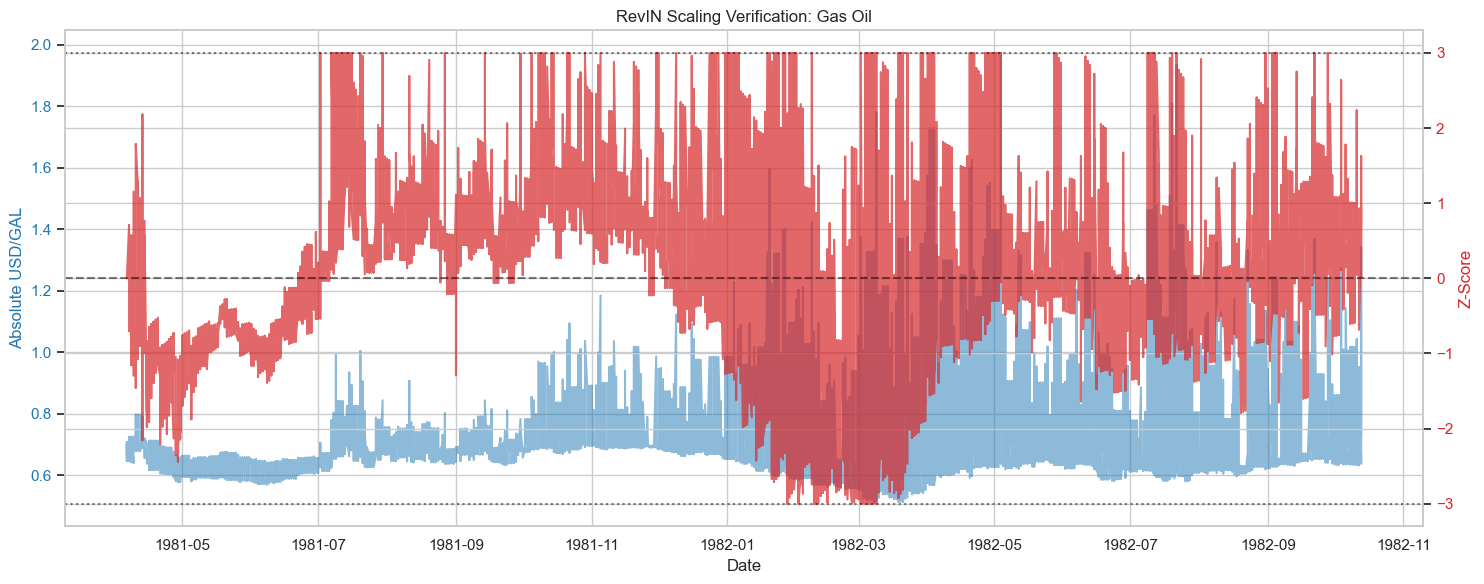

In [32]:
sample_product = 'Gas Oil'
query_plot = f"""
SELECT ASSESSDATE, NORMALIZED_VALUE_USD_GAL, Z_SCORE
FROM CMDTYA.PUBLIC.PRICEDATA_ML_READY
WHERE PRODUCT = '{sample_product}'
ORDER BY ASSESSDATE
LIMIT 5000
"""
df_plot = sf.read_sql(query_plot)
df_plot['ASSESSDATE'] = pd.to_datetime(df_plot['ASSESSDATE'])

fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Absolute USD/GAL', color=color)
ax1.plot(df_plot['ASSESSDATE'], df_plot['NORMALIZED_VALUE_USD_GAL'], color=color, alpha=0.5, label='Raw USD/GAL')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Z-Score', color=color)
ax2.plot(df_plot['ASSESSDATE'], df_plot['Z_SCORE'], color=color, alpha=0.7, label='RevIN Z-Score')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.axhline(3, color='black', linestyle=':', alpha=0.5)
ax2.axhline(-3, color='black', linestyle=':', alpha=0.5)

plt.title(f'RevIN Scaling Verification: {sample_product}')
fig.tight_layout()
plt.show()


In [33]:
sf.close()